In [1]:
from utils import *
from FAPT import *
from DRAG import * 
simulation = Simulation()
dim_q1, dim_q2, dim_c = (3,3,3)


In [2]:
import time
import numpy as np
import sympy as sp
from IPython.display import display, Math

print("[Block 1] Initialisiere rein symbolische Parameter, Energien & hermitesches V1...")
start_time = time.perf_counter()

# 1.1 Zeit- und Puls-Symbole
t_sym = sp.Symbol('t', real=True, positive=True)
tg_sym = sp.Symbol('t_g', real=True, positive=True)
sigma_sym = sp.Symbol(r'\sigma', real=True, positive=True)

# 1.2 Frequenz- und Steuer-Symbole
wd0_sym = sp.Symbol(r'\omega_{d0}', real=True)
dwd_t_sym = sp.Function(r'\delta\omega_d', real=True)(t_sym)
wd_t_sym = wd0_sym + dwd_t_sym

# Komplexes A(t) = A_r(t) + i A_i(t)
Ar_sym = sp.Function('A_r', real=True)(t_sym)
Ai_sym = sp.Function('A_i', real=True)(t_sym)
A_t_sym = Ar_sym + sp.I * Ai_sym

# Freie physikalische System-Parameter
Delta_sym = sp.Symbol('Delta', real=True)
lam_sym = sp.Symbol('lambda', real=True)

# 1.3 Symbolische Energien E_array aus Dimensionen erzeugen
D = 27
E_array_sym = np.array([sp.Symbol(f"E_{i}", real=True) for i in range(D)])

# 2.1 V0 als explizite symbolische Nullmatrix
V0_sym = sp.zeros(D, D)

# 2.2 V1_dressed_array als Betrags-Referenz heranziehen
V1_dressed_ref = simulation.V1_dressed_array
threshold = 1e-8

# V1 mit Bra-Ket Symbolen belegen NUR WO |V1_dressed| >= threshold
V1_sym = np.zeros((D, D), dtype=object)

for i1 in range(dim_q1):
    for i2 in range(dim_q2):
        for ic in range(dim_c):
            for jc in range(dim_c):
                for j1 in range(dim_q1):
                    for j2 in range(dim_q2):
                        i = i1 * dim_c * dim_q2 + ic * dim_q2 + i2
                        j = j1 * dim_c * dim_q2 + jc * dim_q2 + j2
                        
                        # Prüfe gegen den absoluten Schwellenwert aus s.V1_dressed_array
                        if np.abs(V1_dressed_ref[i, j]) >= threshold:
                            # Symbolische Bra-Ket Matrixelemente
                            real = i1==j1 and ic==jc and i2==j2
                            bra_ket = sp.Symbol(f"\\bra{{{i1}{ic}{i2}}}\\widetilde{{V_1}}{{\\ket{{{j1}{jc}{j2}}}}}", real=real)
                            V1_sym[i, j] = bra_ket
                        else:
                            V1_sym[i, j] = sp.S.Zero

[Block 1] Initialisiere rein symbolische Parameter, Energien & hermitesches V1...


In [3]:
print("[Block 2] Konstruiere gefilterte symbolische Matrix V1 (V0 = 0) und starte FAPT...")
start_time = time.perf_counter()


# 2.3 FAPT Heff symbolisch aufrufen
print("  ➜ Berechne Heff via FAPT analytisch...", end="", flush=True)
heff_start = time.perf_counter()

Heff_sym = Heff_Floquet_total_matrix_summed(
    rH=getattr(simulation, 'rH', 1),
    wd=wd_t_sym,
    A=A_t_sym,
    resonances=simulation.resonances,
    E=E_array_sym,                  # REIN SYMBOLISCHE ENERGIEN
    V_posHarm=V1_sym,                # GEFILTERTE SYMBOLISCHE BRA-KET MATRIX
    V0=V0_sym,                       # EXPLIZIT SP.ZEROS
    ref_state=getattr(simulation, 'ref_state', None),
    dwd=0,
    dA=0,
    t=t_sym,
    analytics=True,
    include_geometric=False,
    include_micromotion=False,
    include_g_correction=False,
    verbose=False,
    rW=getattr(simulation, 'rW', 1)
)

print(f" Fertig in {time.perf_counter() - heff_start:.2f}s!")

# ==============================================================================
# SYMBOLISCHE KONDENSATION / LINEARISIERUNG
# ==============================================================================
def condense_element_symbolic(expr, var, order=1, factor_vars=None):
    if expr == 0 or expr == sp.S.Zero:
        return sp.S.Zero
    if factor_vars is None:
        factor_vars = []

    terms = sp.Add.make_args(expr)
    linearized_terms = []

    for term in terms:
        if not term.has(var):
            linearized_terms.append(sp.cancel(term))
            continue

        f_0 = term.subs(var, 0)
        if order == 0:
            linearized_terms.append(sp.cancel(f_0))
        elif order == 1:
            df_0 = term.diff(var).subs(var, 0)
            linearized_terms.append(sp.cancel(f_0) + sp.cancel(df_0) * var)

    total_sum = sp.Add(*linearized_terms)
    poly_dwd = sp.Poly(total_sum, var)
    coeffs = poly_dwd.all_coeffs()
    degree = poly_dwd.degree()

    compact_terms = []
    for idx, coeff in enumerate(coeffs):
        current_pow = degree - idx
        coeff_factored = sp.factor(sp.collect(coeff, factor_vars))
        if current_pow == 0:
            compact_terms.append(coeff_factored)
        else:
            compact_terms.append(coeff_factored * (var**current_pow))

    return sp.Add(*compact_terms)

# Linearisierung der symbolischen Matrix
H_eff_raw = sp.Matrix(Heff_sym)
delta_shift = H_eff_raw[0, 0]
H_eff_shifted = H_eff_raw - delta_shift * sp.eye(H_eff_raw.shape[0])

rows, cols = H_eff_shifted.rows, H_eff_shifted.cols
Heff = sp.zeros(rows, cols)

for i in range(rows):
    for j in range(cols):
        elem = H_eff_shifted[i, j]
        if elem != 0:
            Heff[i, j] = condense_element_symbolic(elem, dwd_t_sym, order=1, factor_vars=[Ar_sym, Ai_sym])

Delta = -2*Heff[1,1] + Heff[2,2]
lam_val = Heff[0,1] / Heff[1,2]

display(Delta)
print(f"✅ Block 2 abgeschlossen in {time.perf_counter() - start_time:.2f}s\n")
display(Math(rf"(H_{{\text{{eff}}}})_{{0,1}} = {sp.latex(Heff[0, 1])}"))
display(Math(rf"(H_{{\text{{eff}}}})_{{1,2}} = {sp.latex(Heff[1,2])}"))

[Block 2] Konstruiere gefilterte symbolische Matrix V1 (V0 = 0) und starte FAPT...
  ➜ Berechne Heff via FAPT analytisch... Fertig in 0.02s!


E_1 + E_3 - 2*E_9

✅ Block 2 abgeschlossen in 0.05s



<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
print("[Block 3] Berechne H_target via DRAG mit symbolischen Zeitparametern...")
start_time = time.perf_counter()

H_target_raw, subs_ht = h_target_symbolic_abstract(
    Delta=Delta_sym,
    rrr=lam_sym, 
    tg=tg_sym,               # SYMBOLISCHES tg
    sigma_r=sigma_sym, # SYMBOLISCHES sigma (sigma_r = sigma / tg)
    pulse='gauss', 
    t=t_sym, 
    order=4
)

H_target = sp.Matrix(H_target_raw).doit()

print(f"✅ Block 3 abgeschlossen in {time.perf_counter() - start_time:.2f}s\n")

[Block 3] Berechne H_target via DRAG mit symbolischen Zeitparametern...
✅ Block 3 abgeschlossen in 0.01s



In [5]:
import time
import sympy as sp
from IPython.display import display, Math

print("[Block 4] Extrahiere die 3 Bestimmungsgleichungen aus H_eff und H_target...")
start_time = time.perf_counter()

# 1. Differenzmatrix bilden
H_diff = Heff - H_target

# 2. Hilfssymbole und exakte Teilausdrücke zur Ersetzung
# N_sigma = sp.Symbol(r'\mathcal{N}_\sigma', real=True, positive=True)
# g_t = sp.Symbol(r'g(t)', real=True)
N_sigma = sp.Function(r'\mathcal{N}_\sigma', real=True, positive=True)
g = sp.Function('g', real=True)

expr_N_sigma = sp.sqrt(2)*sp.sqrt(sp.pi)*sigma_sym*sp.erf(sp.sqrt(2)*tg_sym/(4*sigma_sym)) - tg_sym*sp.exp(-tg_sym**2/(8*sigma_sym**2))
expr_g_t = sp.exp(-(t_sym - tg_sym/2)**2 / (2*sigma_sym**2)) - sp.exp(-tg_sym**2 / (8*sigma_sym**2))

# subs_map = {
#     N_sigma(t_sym):expr_N_sigma,
#     g(t_sym):expr_g_t
# }
subs_map = {
}

# 3. Dynamische Extraktion aus den Matrixelementen und Ersetzung anwenden
raw_re_01 = sp.re(H_diff[0, 1]).subs(subs_map)
raw_im_01 = sp.im(H_diff[0, 1]).subs(subs_map)
raw_diag_11 = sp.re(H_diff[1, 1]).subs(subs_map)

# Gleichungen mit explizitem "= 0"
equations = [
    sp.Eq(raw_re_01, 0),
    sp.Eq(raw_im_01, 0),
    sp.Eq(raw_diag_11, 0)
]

print(f"✅ Block 4 abgeschlossen in {time.perf_counter() - start_time:.2f}s")
print("  -> 3 Gleichungen dynamisch extrahiert.\n")

# 4. Strings für LaTeX-Ausgabe aufbereiten
str_eq1 = sp.latex(equations[0])
str_eq2 = sp.latex(equations[1])
str_eq3 = sp.latex(equations[2])

display(Math(rf"\text{{1. }} A_r(t)\text{{-Gl. (Re 0,1)}}: \quad {str_eq1}"))
display(Math(rf"\text{{2. }} A_i(t)\text{{-Gl. (Im 0,1)}}: \quad {str_eq2}"))
display(Math(rf"\text{{3. }} \delta\omega_d(t)\text{{-Gl. (Diag 1,1)}}: \quad {str_eq3}"))

# 5. LaTeX-Code inklusive Definition der Hilfsfunktionen generieren
latex_system_code = rf"""% --- Definition der Hilfsfunktionen ---
\begin{{aligned}}
  \mathcal{{N}}_\sigma &= {sp.latex(expr_N_sigma)} \\[1.5ex]
  g(t) &= {sp.latex(expr_g_t)}
\end{{aligned}}

% --- Bestimmungsgleichungen ---
\begin{{aligned}}
  \text{{1. }} A_r(t)\text{{-Gl. (Re 0,1)}} &: \quad {str_eq1} \\[2ex]
  \text{{2. }} A_i(t)\text{{-Gl. (Im 0,1)}} &: \quad {str_eq2} \\[2ex]
  \text{{3. }} \delta\omega_d(t)\text{{-Gl. (Diag 1,1)}} &: \quad {str_eq3}
\end{{aligned}}"""

# 6. Ausgabe als Roh-Text zum Kopieren
print("\n--- REINER LATEX-CODE (ZUM KOPIEREN) ---")
print(latex_system_code)

[Block 4] Extrahiere die 3 Bestimmungsgleichungen aus H_eff und H_target...
✅ Block 4 abgeschlossen in 0.01s
  -> 3 Gleichungen dynamisch extrahiert.



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- REINER LATEX-CODE (ZUM KOPIEREN) ---
% --- Definition der Hilfsfunktionen ---
\begin{aligned}
  \mathcal{N}_\sigma &= \sqrt{2} \sqrt{\pi} \sigma \operatorname{erf}{\left(\frac{\sqrt{2} t_{g}}{4 \sigma} \right)} - t_{g} e^{- \frac{t_{g}^{2}}{8 \sigma^{2}}} \\[1.5ex]
  g(t) &= e^{- \frac{\left(t - \frac{t_{g}}{2}\right)^{2}}{2 \sigma^{2}}} - e^{- \frac{t_{g}^{2}}{8 \sigma^{2}}}
\end{aligned}

% --- Bestimmungsgleichungen ---
\begin{aligned}
  \text{1. } A_r(t)\text{-Gl. (Re 0,1)} &: \quad - \frac{A_{i}{\left(t \right)} \operatorname{im}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)}}{2} + \frac{A_{r}{\left(t \right)} \operatorname{re}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)}}{2} - \frac{\operatorname{{\mathcal E}}_\pi{\left(t \right)}}{2} = 0 \\[2ex]
  \text{2. } A_i(t)\text{-Gl. (Im 0,1)} &: \quad - \frac{A_{i}{\left(t \right)} \operatorname{re}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)}}{2} - \frac{A_{r}{\left(t \right)} \operatorname{im}{\left(\bra{100}\widetil

In [6]:
# 1. dwd aus Gl. 3 auflösen
sol_dwd = sp.solve(equations[2], dwd_t_sym)[0]

# 2. Gleichungen vorerst normal expandieren
V1_diag_list = list(V1_sym.diagonal())

eq1_expanded = equations[0].expand(complex=True)
eq2_expanded = equations[1].expand(complex=True)

# 3. A_i und A_r bestimmen
sol_Ai_from_eq2 = sp.solve(eq2_expanded, Ai_sym)[0]
sol_Ar_from_eq1 = sp.solve(eq1_expanded, Ai_sym)[0]

eq_Ar = sp.Eq(sol_Ar_from_eq1.subs(Ai_sym, sol_Ai_from_eq2), Ar_sym)
sol_Ar = sp.solve(eq_Ar, Ar_sym)[0]
sol_Ai = sol_Ai_from_eq2.subs(Ar_sym, sol_Ar)


# 4. Ersetzung NACH dem Lösen auf die Ergebnisse anwenden
im_zero_subs = {
    **{sp.im(elem): 0 for elem in V1_diag_list},
    **{sp.conjugate(elem): elem for elem in V1_diag_list}
}

sol_Ar = sol_Ar.subs(im_zero_subs)
sol_Ai = sol_Ai.subs(im_zero_subs)
sol_dwd = sol_dwd.subs(im_zero_subs)

# 5. LaTeX-Strings erstellen
str_Ar = sp.latex(sp.Eq(Ar_sym, sol_Ar))
str_Ai = sp.latex(sp.Eq(Ai_sym, sol_Ai))
str_dwd = sp.latex(sp.Eq(dwd_t_sym, sol_dwd))

# 6. Anzeige aller drei Lösungen
display(Math(rf"\text{{Hauptamplitude }} A_r(t): \quad {str_Ar}"))
display(Math(rf"\text{{DRAG-Korrektur }} A_i(t): \quad {str_Ai}"))
display(Math(rf"\text{{Frequenzkorrektur }} \delta\omega_d(t): \quad {str_dwd}"))
# 7. Reiner LaTeX-Code zum Kopieren
latex_output = rf"""\begin{{aligned}}
  A_r(t) &= {sp.latex(sol_Ar)} \\[2ex]
  A_i(t) &= {sp.latex(sol_Ai)} \\[2ex]
  \delta\omega_d(t) &= {sp.latex(sol_dwd)}
\end{{aligned}}"""

print("\n--- REINER LATEX-CODE (ZUM KOPIEREN) ---")
print(latex_output)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- REINER LATEX-CODE (ZUM KOPIEREN) ---
\begin{aligned}
  A_r(t) &= \frac{\operatorname{{\mathcal E}}_\pi{\left(t \right)}}{\operatorname{re}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)} - \operatorname{im}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)}} \\[2ex]
  A_i(t) &= \frac{- \frac{\Delta \operatorname{{\mathcal E}}_\pi{\left(t \right)} \operatorname{im}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)}}{\operatorname{re}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)} - \operatorname{im}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)}} - \operatorname{re}{\left(\frac{d}{d t} \operatorname{{\mathcal E}}_\pi{\left(t \right)}\right)}}{\Delta \operatorname{re}{\left(\bra{100}\widetilde{V_1}{\ket{001}}\right)}} \\[2ex]
  \delta\omega_d(t) &= \frac{\Delta \left(- E_{1} + E_{9} - \omega_{d0}\right) - \frac{\lambda^{2} \operatorname{{\mathcal E}}_\pi^{2}{\left(t \right)}}{4} + \operatorname{{\mathcal E}}_\pi^{2}{\left(t \right)}}{\Delta}
\end{aligned}


Symbolisch berechneter Offset: wd0 = -3.438043e+00
Finale Kontrolle -> dwd_vals_raw[0] ist exakt: 0.0


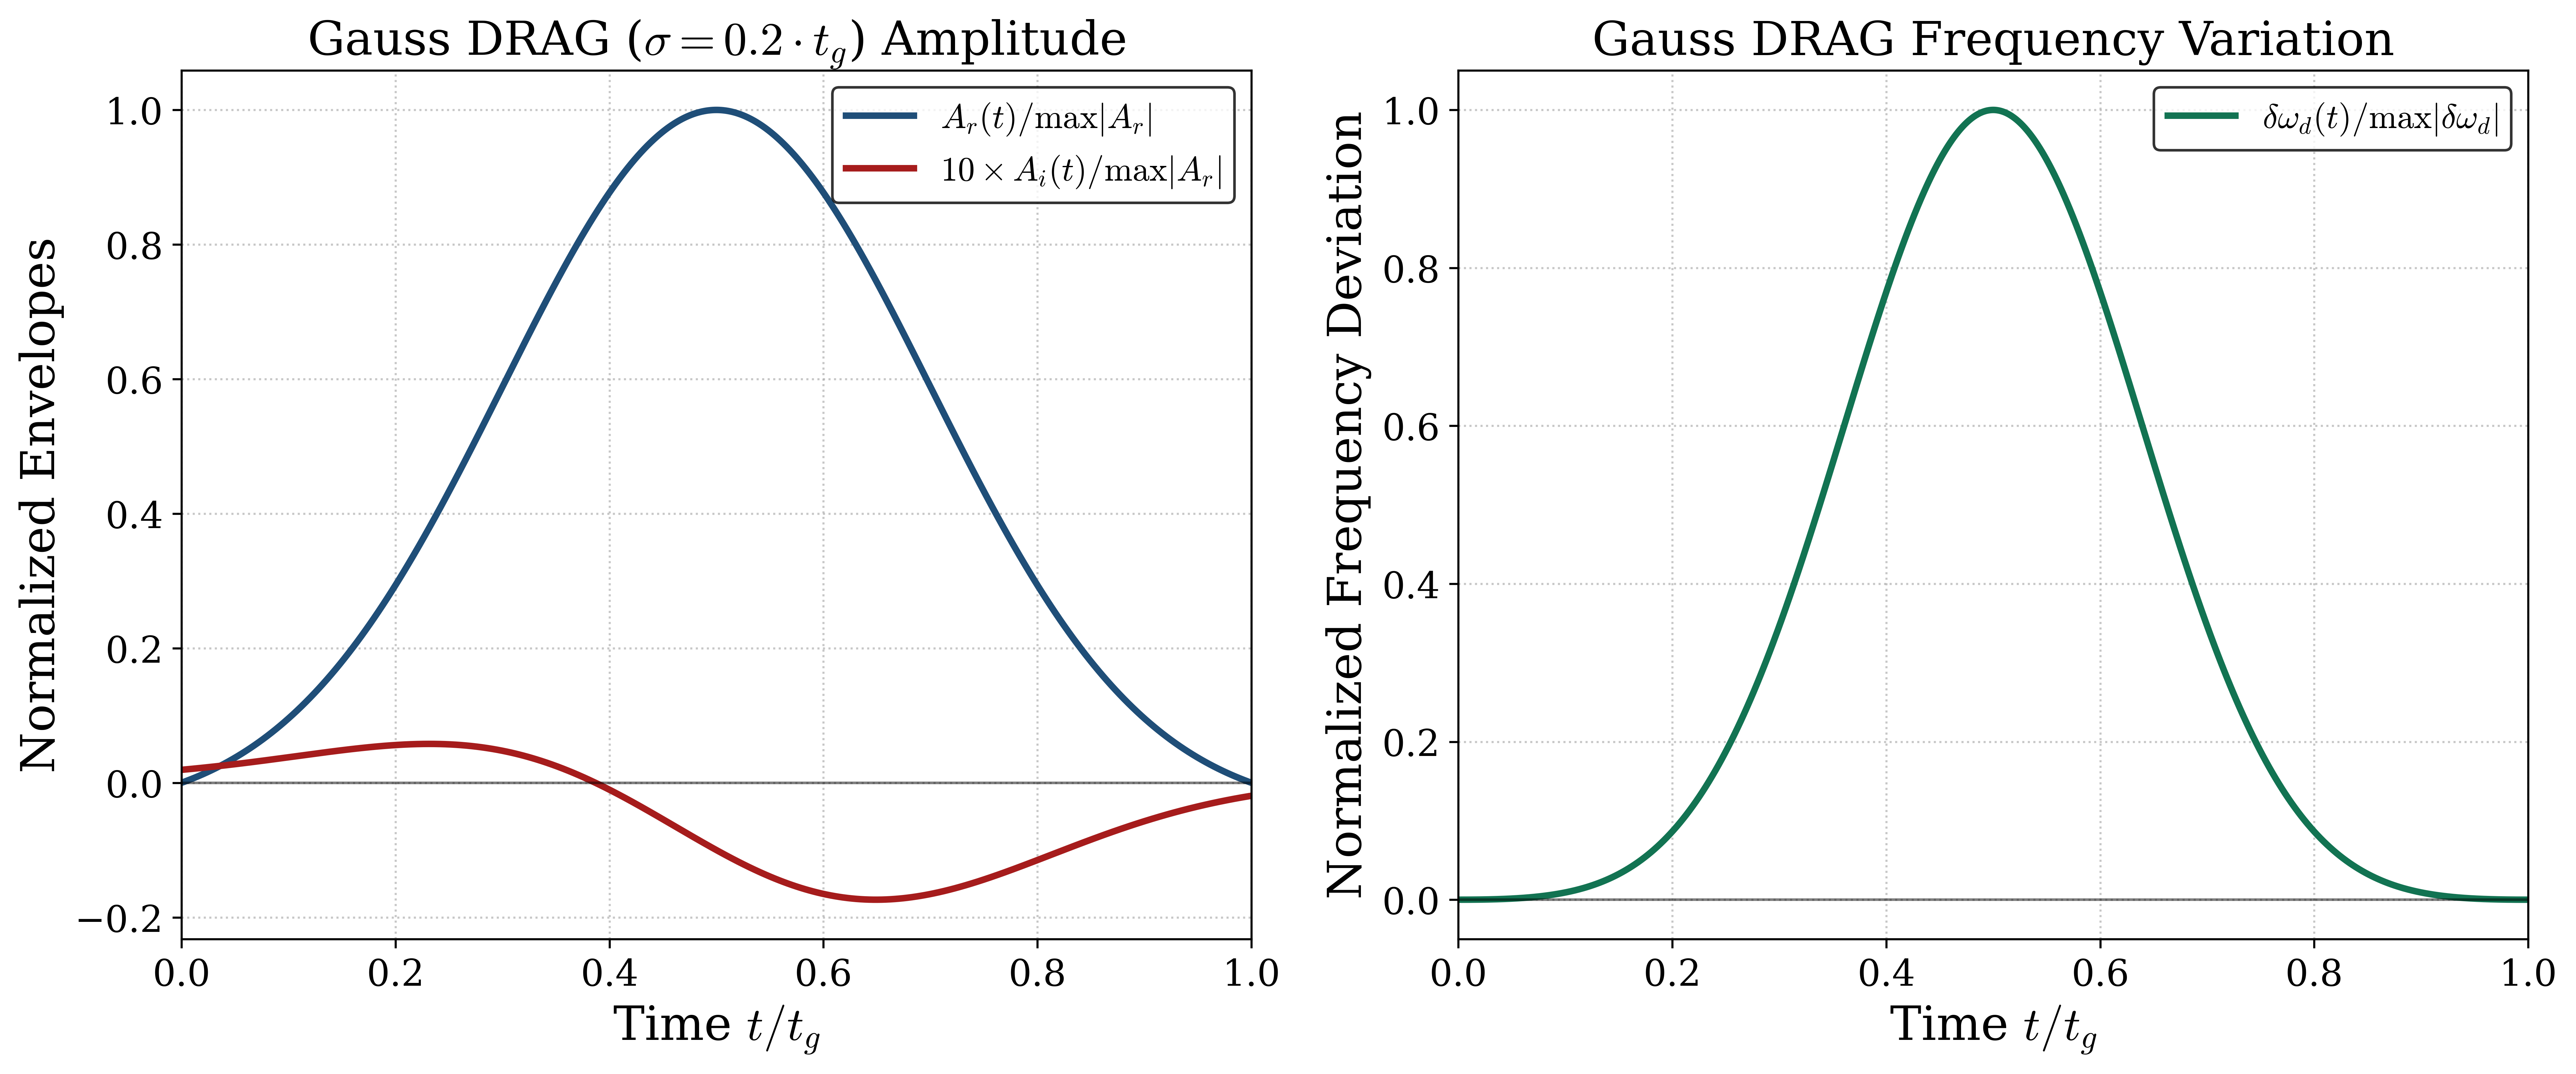

In [7]:
# ==============================================================================
# BLOCK 7: PAPER STYLE PLOT (DWD OFFSET AT t=0 & NORMED PLOT)
# ==============================================================================

import re
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# ------------------------------------------------------------------------------
# 1. Physikalische Parameter festlegen
# ------------------------------------------------------------------------------
tg_val = 250.0  # Gate-Zeit [ns]
delta_val = -1.18  # Anharmonizität [rad/ns]
sigma_val = 0.2  # Sigma
lambda_val = 10

all_symbols = sol_Ar.free_symbols | sol_Ai.free_symbols | sol_dwd.free_symbols
ht_exprs = [v for v in subs_ht.values() if isinstance(v, sp.Basic)]
ht_symbols = set().union(*(expr.free_symbols for expr in ht_exprs))
combined_symbols = all_symbols | ht_symbols
sym_map = {s.name: s for s in combined_symbols}

t_sym_plot = sym_map.get("t", sp.Symbol("t"))

# wd0 als freies Symbol behalten (NICHT vorab auf 0 setzen!)
wd0_sym = sym_map.get("omega_{d0}", sym_map.get("wd0", sp.Symbol("omega_{d0}")))

# ------------------------------------------------------------------------------
# 2. Parameter-Substitution (ohne wd0)
# ------------------------------------------------------------------------------
params = {}
for s in combined_symbols:
  s_name_lower = s.name.lower()
  if "sigma" in s_name_lower or s == sigma_sym:
    params[s] = sigma_val
  elif "t_g" in s_name_lower or "tg" in s_name_lower or s == tg_sym:
    params[s] = tg_val
  elif "delta" in s_name_lower:
    params[s] = delta_val

for symbol in combined_symbols:
  if symbol not in params and symbol != t_sym_plot and symbol != wd0_sym:
    name = symbol.name
    if "100" in name or "001" in name:
      params[symbol] = 1.0 + 0.01j
    elif "lambda" in name.lower():
      params[symbol] = lambda_val
    elif "E" in name:
      index = int(name.split('_')[1])
      params[symbol] = simulation.E_array[index]
    else:
      params[symbol] = 1.0

# ------------------------------------------------------------------------------
# 3. Pulsfunktionen auflösen & Skalare einsetzen
# ------------------------------------------------------------------------------
numeric_func_map = {}
for func_sym, func_expr in subs_ht.items():
  if isinstance(func_expr, sp.Basic):
    numeric_func_map[func_sym] = func_expr.doit().subs(params)
  else:
    numeric_func_map[func_sym] = func_expr

Ar_sub = sol_Ar.subs(numeric_func_map).subs(params)
Ai_sub = sol_Ai.subs(numeric_func_map).subs(params)
dwd_sub = sol_dwd.subs(numeric_func_map).subs(params)

# ------------------------------------------------------------------------------
# 4. Hilfsfunktion & Exakte Bestimmung des Offsets bei t=0
# ------------------------------------------------------------------------------
def safe_eval(func, t_arr):
  """Sichere numerische Auswertung zur Vermeidung von NaNs/Infs bei t=0 oder Singularitäten."""
  res = []
  for t_v in t_arr:
    try:
      v = func(t_v)
      if np.isnan(v) or np.isinf(v):
        v = 0.0
    except Exception:
      v = 0.0
    res.append(v)
  return np.array(res)

t_vals = np.linspace(0.0, tg_val, 1000)
t_norm = t_vals / tg_val

# Exaktes Zeit-Symbol aus dwd holen
dwd_free = dwd_sub.free_symbols
t_sym_dwd = next((s for s in dwd_free if s.name == t_sym_plot.name), t_sym_plot)

# 1. Symbolischer Test bei t = 0 & wd0 = 0
dwd_at_zero_expr = dwd_sub.subs({t_sym_dwd: 0.0, wd0_sym: 0.0}).doit()
try:
  wd0_determined = -float(sp.N(dwd_at_zero_expr))
except Exception:
  wd0_determined = 0.0

print(f"Symbolisch berechneter Offset: wd0 = {wd0_determined:.6e}")

# ------------------------------------------------------------------------------
# 5. Zweite Lambdifizierung
# ------------------------------------------------------------------------------
Ar_sub_final = Ar_sub.subs({wd0_sym: wd0_determined}).doit()
Ai_sub_final = Ai_sub.subs({wd0_sym: wd0_determined}).doit()
dwd_sub_final = dwd_sub.subs({wd0_sym: wd0_determined}).doit()

Ar_func = sp.lambdify(t_sym_dwd, Ar_sub_final, modules=["numpy"])
Ai_func = sp.lambdify(t_sym_dwd, Ai_sub_final, modules=["numpy"])
dwd_func = sp.lambdify(t_sym_dwd, dwd_sub_final, modules=["numpy"])

# Array-Auswertung
Ar_vals = np.real_if_close(safe_eval(Ar_func, t_vals)).real
Ai_vals = np.real_if_close(safe_eval(Ai_func, t_vals)).real
dwd_vals_raw = np.real_if_close(safe_eval(dwd_func, t_vals)).real

if dwd_vals_raw.shape != t_vals.shape:
  dwd_vals_raw = np.full_like(t_vals, fill_value=float(dwd_vals_raw.squeeze()))

# FAILSAFE: Numerische Erdung bei t=0
dwd_vals_raw = dwd_vals_raw - dwd_vals_raw[0]

print(f"Finale Kontrolle -> dwd_vals_raw[0] ist exakt: {dwd_vals_raw[0]}")

# ------------------------------------------------------------------------------
# 6. Normierung auf das Betragsmaximum
# ------------------------------------------------------------------------------
Ar_peak = np.max(np.abs(Ar_vals))
if Ar_peak == 0 or np.isnan(Ar_peak):
  Ar_peak = 1.0

dwd_peak = np.max(np.abs(dwd_vals_raw))
if dwd_peak == 0 or np.isnan(dwd_peak):
  dwd_peak = 1.0

Ar_norm = Ar_vals / Ar_peak
Ai_norm = Ai_vals / Ar_peak
dwd_norm = dwd_vals_raw / dwd_peak

# ------------------------------------------------------------------------------
# 7. PAPER STYLE PLOT
# ------------------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 13,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "lines.linewidth": 2.5,
    "figure.dpi": 600,
    "mathtext.fontset": "cm",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Amplituden ---
ax1.plot(t_norm, Ar_norm, color="#1f4e78", label=r"$A_r(t) / \max|A_r|$")
ax1.plot(
    t_norm,
    10 * Ai_norm,
    color="#a61c1c",
    linestyle="-",
    label=r"$10\times A_i(t) / \max|A_r|$",
)
ax1.set_xlabel(r"Time $t/t_g$")
ax1.set_ylabel("Normalized Envelopes")
ax1.set_title(r"Gauss DRAG ($\sigma = " + str(sigma_val) + r"\cdot t_g$) Amplitude")
ax1.legend(loc="upper right", frameon=True, edgecolor="black")
ax1.grid(True, linestyle=":", alpha=0.7)
ax1.axhline(0, color="black", linewidth=1.0, alpha=0.5)
ax1.set_xlim(0, 1)

# --- Subplot 2: Dynamic Frequency Shift (Auf Maximum normiert) ---
ax2.plot(
    t_norm,
    dwd_norm,
    color="#127352",
    label=r"$\delta\omega_d(t) / \max|\delta\omega_d|$",
)
ax2.set_xlabel(r"Time $t/t_g$")
ax2.set_ylabel("Normalized Frequency Deviation")
ax2.set_title("Gauss DRAG Frequency Variation")
ax2.legend(loc="upper right", frameon=True, edgecolor="black")
ax2.grid(True, linestyle=":", alpha=0.7)
ax2.axhline(0, color="black", linewidth=1.0, alpha=0.5)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("Figure/drag_pulse_shapes.pdf", bbox_inches="tight")
plt.show()